In [ ]:
!pip install -q scikit-surprise

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 38.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import ast
import warnings
warnings.filterwarnings("ignore")

In [ ]:
movies = pd.read_csv("data/movies_metadata.csv", low_memory=False)
credits = pd.read_csv("data/credits.csv")
keywords = pd.read_csv("data/keywords.csv")
ratings = pd.read_csv("data/ratings_small.csv")
links = pd.read_csv("data/links_small.csv")

In [ ]:
movies.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [ ]:
movies.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [ ]:
movies.describe()

,revenue,runtime,vote_average,vote_count
count,4.546000e+04,45203.000000,45460.000000,45460.000000
mean,1.120935e+07,94.128199,5.618207,109.897338
std,6.433225e+07,38.407810,1.924216,491.310374
min,0.000000e+00,0.000000,0.000000,0.000000
25%,0.000000e+00,85.000000,5.000000,3.000000
50%,0.000000e+00,95.000000,6.000000,10.000000
75%,0.000000e+00,107.000000,6.800000,34.000000
max,2.787965e+09,1256.000000,10.000000,14075.000000


In [ ]:
movies.isnull().sum()

,0
adult,0
belongs_to_collection,40972
budget,0
genres,0
homepage,37684
id,0
imdb_id,17
original_language,11
original_title,0
overview,954


In [ ]:
credits.head()

,cast,crew,id
0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...",862
1,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...",8844
2,"[{'cast_id': 2, 'character': 'Max Goldman', 'c...","[{'credit_id': '52fe466a9251416c75077a89', 'de...",15602
3,"[{'cast_id': 1, 'character': ""Savannah 'Vannah...","[{'credit_id': '52fe44779251416c91011acb', 'de...",31357
4,"[{'cast_id': 1, 'character': 'George Banks', '...","[{'credit_id': '52fe44959251416c75039ed7', 'de...",11862


In [ ]:
credits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45476 entries, 0 to 45475
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   cast    45476 non-null  object
 1   crew    45476 non-null  object
 2   id      45476 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.0+ MB


In [ ]:
credits.isnull().sum()

,0
cast,0
crew,0
id,0


In [ ]:
keywords.head()

,id,keywords
0,862,"[{'id': 931, 'name': 'jealousy'}, {'id': 4290,..."
1,8844,"[{'id': 10090, 'name': 'board game'}, {'id': 1..."
2,15602,"[{'id': 1495, 'name': 'fishing'}, {'id': 12392..."
3,31357,"[{'id': 818, 'name': 'based on novel'}, {'id':..."
4,11862,"[{'id': 1009, 'name': 'baby'}, {'id': 1599, 'n..."


In [ ]:
keywords.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46419 entries, 0 to 46418
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        46419 non-null  int64 
 1   keywords  46419 non-null  object
dtypes: int64(1), object(1)
memory usage: 725.4+ KB


In [ ]:
keywords.isnull().sum()

,0
id,0
keywords,0


In [ ]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


In [ ]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100004 entries, 0 to 100003
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100004 non-null  int64  
 1   movieId    100004 non-null  int64  
 2   rating     100004 non-null  float64
 3   timestamp  100004 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [ ]:
ratings.isnull().sum()

,0
userId,0
movieId,0
rating,0
timestamp,0


In [ ]:
ratings.describe()

,userId,movieId,rating,timestamp
count,100004.000000,100004.000000,100004.000000,1.000040e+05
mean,347.011310,12548.664363,3.543608,1.129639e+09
std,195.163838,26369.198969,1.058064,1.916858e+08
min,1.000000,1.000000,0.500000,7.896520e+08
25%,182.000000,1028.000000,3.000000,9.658478e+08
50%,367.000000,2406.500000,4.000000,1.110422e+09
75%,520.000000,5418.000000,4.000000,1.296192e+09
max,671.000000,163949.000000,5.000000,1.476641e+09


In [ ]:
links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [ ]:
links.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9125 entries, 0 to 9124
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  9125 non-null   int64  
 1   imdbId   9125 non-null   int64  
 2   tmdbId   9112 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 214.0 KB


In [ ]:
links.isnull().sum()

,0
movieId,0
imdbId,0
tmdbId,13


In [ ]:
links.describe()

,movieId,imdbId,tmdbId
count,9125.000000,9.125000e+03,9112.000000
mean,31123.291836,4.798244e+05,39104.545544
std,40782.633604,7.431774e+05,62814.519801
min,1.000000,4.170000e+02,2.000000
25%,2850.000000,8.884600e+04,9451.750000
50%,6290.000000,1.197780e+05,15852.000000
75%,56274.000000,4.284410e+05,39160.500000
max,164979.000000,5.794766e+06,416437.000000


In [ ]:
# Create the copies of the datasets
movies_df = movies.copy()
credits_df = credits.copy()
keywords_df = keywords.copy()
ratings_df = ratings.copy()
links_df = links.copy()

In [ ]:
movies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

In [ ]:
# Keep only valid numeric movie IDs
movies_df = movies_df[movies_df['id'].str.isnumeric()]
movies_df['id'] = movies_df['id'].astype(int)

In [ ]:
movies_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45463 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45463 non-null  object 
 1   belongs_to_collection  4491 non-null   object 
 2   budget                 45463 non-null  object 
 3   genres                 45463 non-null  object 
 4   homepage               7779 non-null   object 
 5   id                     45463 non-null  int64  
 6   imdb_id                45446 non-null  object 
 7   original_language      45452 non-null  object 
 8   original_title         45463 non-null  object 
 9   overview               44509 non-null  object 
 10  popularity             45460 non-null  object 
 11  poster_path            45077 non-null  object 
 12  production_companies   45460 non-null  object 
 13  production_countries   45460 non-null  object 
 14  release_date           45376 non-null  object 
 15  revenue

In [ ]:
# Rename columns for merging
credits_df.rename(columns={"id": "movie_id"}, inplace=True)
keywords_df.rename(columns={"id": "movie_id"}, inplace=True)

movies_df.rename(columns={"id": "movie_id"}, inplace=True)

In [ ]:
# Remove duplicate movies
movies_df.drop_duplicates(subset="movie_id", inplace=True)
credits_df.drop_duplicates(subset="movie_id", inplace=True)
keywords_df.drop_duplicates(subset="movie_id", inplace=True)

In [ ]:
print(movies_df.shape)
print(credits_df.shape)
print(keywords_df.shape)

(45433, 24)
(45432, 3)
(45432, 2)


In [ ]:
# Selected only useful columns
movies_df = movies_df[
    [
        "movie_id",
        "title",
        "genres",
        "overview",
        "popularity",
        "release_date",
        "vote_average",
        "vote_count",
        "original_language"
    ]
]

In [ ]:
movies_df.head()

,movie_id,title,genres,overview,popularity,release_date,vote_average,vote_count,original_language
0,862,Toy Story,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...","Led by Woody, Andy's toys live happily in his ...",21.946943,1995-10-30,7.7,5415.0,en
1,8844,Jumanji,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",When siblings Judy and Peter discover an encha...,17.015539,1995-12-15,6.9,2413.0,en
2,15602,Grumpier Old Men,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",A family wedding reignites the ancient feud be...,11.7129,1995-12-22,6.5,92.0,en
3,31357,Waiting to Exhale,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...","Cheated on, mistreated and stepped on, the wom...",3.859495,1995-12-22,6.1,34.0,en
4,11862,Father of the Bride Part II,"[{'id': 35, 'name': 'Comedy'}]",Just when George Banks has recovered from his ...,8.387519,1995-02-10,5.7,173.0,en


In [ ]:
movies_df.isnull().sum()

,0
movie_id,0
title,3
genres,0
overview,954
popularity,3
release_date,87
vote_average,3
vote_count,3
original_language,11


In [ ]:
movies_df.dropna(
    subset=["title", "overview"],
    inplace=True
)

In [ ]:
movies_df.fillna("", inplace=True)

In [ ]:
movies_df.isnull().sum()

,0
movie_id,0
title,0
genres,0
overview,0
popularity,0
release_date,0
vote_average,0
vote_count,0
original_language,0


In [ ]:
# Clean ratings data
ratings_df.head()

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


In [ ]:
ratings_df = ratings_df[
    [
        "userId",
        "movieId",
        "rating"
    ]
]

In [ ]:
ratings_df.isnull().sum()

,0
userId,0
movieId,0
rating,0


In [ ]:
# Clean links data
links_df = links_df[
    [
        "movieId",
        "tmdbId"
    ]
]

In [ ]:
links_df.dropna(inplace=True)

In [ ]:
# Convert TMDB IDs to integers:
links_df["tmdbId"] = links_df["tmdbId"].astype(int)

In [ ]:
links_df.rename(
    columns={"tmdbId": "movie_id"},
    inplace=True
)

In [ ]:
links_df.head()

,movieId,movie_id
0,1,862
1,2,8844
2,3,15602
3,4,31357
4,5,11862


Merge datasets

Merge movie details with credits:

In [ ]:
movies_df = movies_df.merge(
    credits_df,
    on="movie_id",
    how="left"
)

In [ ]:
movies_df = movies_df.merge(
    keywords_df,
    on="movie_id",
    how="left"
)

In [ ]:
movies_df = movies_df.merge(
    links_df,
    on="movie_id",
    how="inner"
)

In [ ]:
movies_df.head()

,movie_id,title,genres,overview,popularity,release_date,vote_average,vote_count,original_language,cast,crew,keywords,movieId
0,862,Toy Story,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...","Led by Woody, Andy's toys live happily in his ...",21.946943,1995-10-30,7.7,5415.0,en,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...","[{'id': 931, 'name': 'jealousy'}, {'id': 4290,...",1
1,8844,Jumanji,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",When siblings Judy and Peter discover an encha...,17.015539,1995-12-15,6.9,2413.0,en,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...","[{'id': 10090, 'name': 'board game'}, {'id': 1...",2
2,15602,Grumpier Old Men,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",A family wedding reignites the ancient feud be...,11.7129,1995-12-22,6.5,92.0,en,"[{'cast_id': 2, 'character': 'Max Goldman', 'c...","[{'credit_id': '52fe466a9251416c75077a89', 'de...","[{'id': 1495, 'name': 'fishing'}, {'id': 12392...",3
3,31357,Waiting to Exhale,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...","Cheated on, mistreated and stepped on, the wom...",3.859495,1995-12-22,6.1,34.0,en,"[{'cast_id': 1, 'character': ""Savannah 'Vannah...","[{'credit_id': '52fe44779251416c91011acb', 'de...","[{'id': 818, 'name': 'based on novel'}, {'id':...",4
4,11862,Father of the Bride Part II,"[{'id': 35, 'name': 'Comedy'}]",Just when George Banks has recovered from his ...,8.387519,1995-02-10,5.7,173.0,en,"[{'cast_id': 1, 'character': 'George Banks', '...","[{'credit_id': '52fe44959251416c75039ed7', 'de...","[{'id': 1009, 'name': 'baby'}, {'id': 1599, 'n...",5


In [ ]:
movies_df.shape

(9070, 13)

In [ ]:
movies_df.isnull().sum()

,0
movie_id,0
title,0
genres,0
overview,0
popularity,0
release_date,0
vote_average,0
vote_count,0
original_language,0
cast,0


Saved the cleaned data

In [ ]:
movies_df.to_csv(
    "data/clean_movies.csv",
    index=False
)

# Feature Engineering

In [ ]:
import ast

Convert Genres

In [ ]:
def convert(text):
    L = []
    if pd.isna(text):
        return L

    try:
        for i in ast.literal_eval(text):
            L.append(i['name'])
    except:
        pass

    return L

In [ ]:
movies_df['genres'] = movies_df['genres'].apply(convert)

In [ ]:
movies_df['genres'].head()

,genres
0,"[Animation, Comedy, Family]"
1,"[Adventure, Fantasy, Family]"
2,"[Romance, Comedy]"
3,"[Comedy, Drama, Romance]"
4,[Comedy]


Convert Keywords

In [ ]:
movies_df['keywords'] = movies_df['keywords'].apply(convert)

In [ ]:
movies_df['keywords'].head()

,keywords
0,"[jealousy, toy, boy, friendship, friends, riva..."
1,"[board game, disappearance, based on children'..."
2,"[fishing, best friend, duringcreditsstinger, o..."
3,"[based on novel, interracial relationship, sin..."
4,"[baby, midlife crisis, confidence, aging, daug..."


Extract Cast

In [ ]:
def convert_cast(text):
    L = []

    if pd.isna(text):
        return L

    try:
        counter = 0

        for i in ast.literal_eval(text):

            if counter != 3:
                L.append(i['name'])
                counter += 1
            else:
                break
    except:
        pass

    return L

In [ ]:
movies_df['cast'] = movies_df['cast'].apply(convert_cast)

In [ ]:
movies_df['cast'].head()

,cast
0,"[Tom Hanks, Tim Allen, Don Rickles]"
1,"[Robin Williams, Jonathan Hyde, Kirsten Dunst]"
2,"[Walter Matthau, Jack Lemmon, Ann-Margret]"
3,"[Whitney Houston, Angela Bassett, Loretta Devine]"
4,"[Steve Martin, Diane Keaton, Martin Short]"


Extract Director

In [ ]:
def fetch_director(text):

    L = []

    if pd.isna(text):
        return L

    try:
        for i in ast.literal_eval(text):

            if i['job'] == 'Director':
                L.append(i['name'])
                break
    except:
        pass

    return L

In [ ]:
movies_df['crew'] = movies_df['crew'].apply(fetch_director)

In [ ]:
movies_df.rename(
    columns={'crew':'director'},
    inplace=True
)

In [ ]:
movies_df['director'].head()

,director
0,[John Lasseter]
1,[Joe Johnston]
2,[Howard Deutch]
3,[Forest Whitaker]
4,[Charles Shyer]


Clean Overview

Convert overview into words.

In [ ]:
movies_df['overview'] = movies_df['overview'].apply(lambda x: x.split())

In [ ]:
movies_df['overview'].head()

,overview
0,"[Led, by, Woody,, Andy's, toys, live, happily,..."
1,"[When, siblings, Judy, and, Peter, discover, a..."
2,"[A, family, wedding, reignites, the, ancient, ..."
3,"[Cheated, on,, mistreated, and, stepped, on,, ..."
4,"[Just, when, George, Banks, has, recovered, fr..."


Remove Spaces

This helps treat names like Tom Hanks as one token (TomHanks).

In [ ]:
movies_df['genres'] = movies_df['genres'].apply(
    lambda x: [i.replace(" ","") for i in x]
)

movies_df['keywords'] = movies_df['keywords'].apply(
    lambda x: [i.replace(" ","") for i in x]
)

movies_df['cast'] = movies_df['cast'].apply(
    lambda x: [i.replace(" ","") for i in x]
)

movies_df['director'] = movies_df['director'].apply(
    lambda x: [i.replace(" ","") for i in x]
)

Create Tags

Combine everything.

In [ ]:
movies_df['tags'] = (
      movies_df['overview']
    + movies_df['genres']
    + movies_df['keywords']
    + movies_df['cast']
    + movies_df['director']
)

In [ ]:
movies_df['tags'].head()

,tags
0,"[Led, by, Woody,, Andy's, toys, live, happily,..."
1,"[When, siblings, Judy, and, Peter, discover, a..."
2,"[A, family, wedding, reignites, the, ancient, ..."
3,"[Cheated, on,, mistreated, and, stepped, on,, ..."
4,"[Just, when, George, Banks, has, recovered, fr..."


Convert Tags to Text

In [ ]:
movies_df['tags'] = movies_df['tags'].apply(lambda x: " ".join(x))

In [ ]:
movies_df[['title','tags']].head()

,title,tags
0,Toy Story,"Led by Woody, Andy's toys live happily in his ..."
1,Jumanji,When siblings Judy and Peter discover an encha...
2,Grumpier Old Men,A family wedding reignites the ancient feud be...
3,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom..."
4,Father of the Bride Part II,Just when George Banks has recovered from his ...


Convert to Lowercase

In [ ]:
movies_df['tags'] = movies_df['tags'].apply(lambda x: x.lower())

Create Final Dataset

Keep only the required columns.

In [ ]:
final_movies = movies_df[
    [
        'movie_id',             # MovielensID
        'movieId',              # TMDB ID for poster
        'title',
        'tags',
        'vote_average',
        'popularity'
    ]
]

In [ ]:
final_movies.head()

,movie_id,movieId,title,tags,vote_average,popularity
0,862,1,Toy Story,"led by woody, andy's toys live happily in his ...",7.7,21.946943
1,8844,2,Jumanji,when siblings judy and peter discover an encha...,6.9,17.015539
2,15602,3,Grumpier Old Men,a family wedding reignites the ancient feud be...,6.5,11.7129
3,31357,4,Waiting to Exhale,"cheated on, mistreated and stepped on, the wom...",6.1,3.859495
4,11862,5,Father of the Bride Part II,just when george banks has recovered from his ...,5.7,8.387519


In [ ]:
final_movies.to_csv(
    "data/final_movies.csv",
    index=False
)

# Exploratory Data Analysis (EDA)

In [ ]:
print("Number of Movies :", final_movies.shape[0])
print("Number of Features :", final_movies.shape[1])

final_movies.head()

Number of Movies : 9070
Number of Features : 6


,movie_id,movieId,title,tags,vote_average,popularity
0,862,1,Toy Story,"led by woody, andy's toys live happily in his ...",7.7,21.946943
1,8844,2,Jumanji,when siblings judy and peter discover an encha...,6.9,17.015539
2,15602,3,Grumpier Old Men,a family wedding reignites the ancient feud be...,6.5,11.7129
3,31357,4,Waiting to Exhale,"cheated on, mistreated and stepped on, the wom...",6.1,3.859495
4,11862,5,Father of the Bride Part II,just when george banks has recovered from his ...,5.7,8.387519


In [ ]:
movies_df[['vote_average', 'vote_count', 'popularity']].describe()

,vote_average,vote_count
count,9070.000000,9070.000000
mean,6.363451,439.622161
std,1.035753,996.691372
min,0.000000,0.000000
25%,5.800000,29.000000
50%,6.500000,97.000000
75%,7.000000,366.000000
max,10.000000,14075.000000


In [ ]:
movies_df.isnull().sum().sort_values(ascending=False)

,0
movie_id,0
title,0
genres,0
overview,0
popularity,0
release_date,0
vote_average,0
vote_count,0
original_language,0
cast,0


In [ ]:
# Top 10 Movie Genres
from collections import Counter

genre_list = []

for genres in movies_df['genres']:
    genre_list.extend(genres)

genre_count = Counter(genre_list)

genre_df = pd.DataFrame(
    genre_count.items(),
    columns=['Genre','Count']
).sort_values(by='Count', ascending=False)

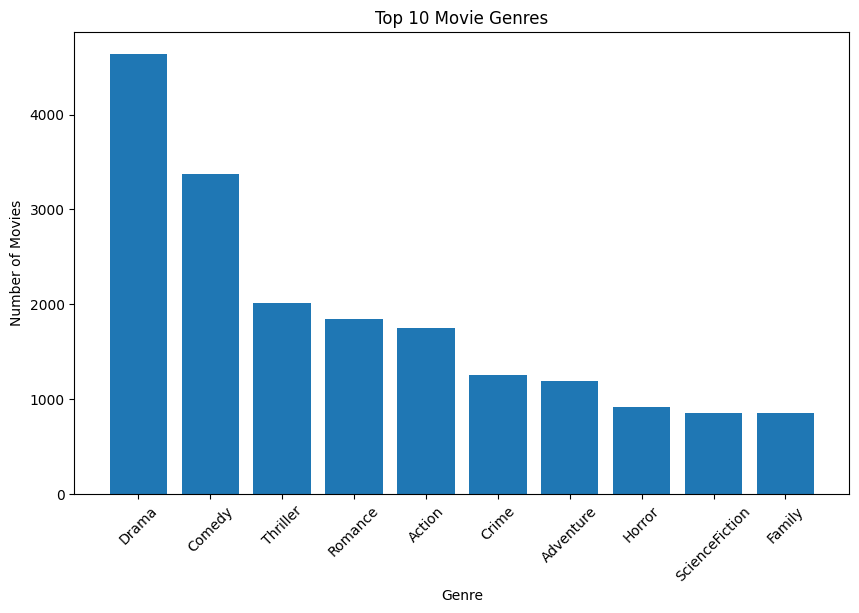

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(
    genre_df['Genre'][:10],
    genre_df['Count'][:10]
)

plt.xticks(rotation=45)
plt.title("Top 10 Movie Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")

plt.show()



Drama and Comedy are the most common genres, indicating that these genres dominate the movie dataset.

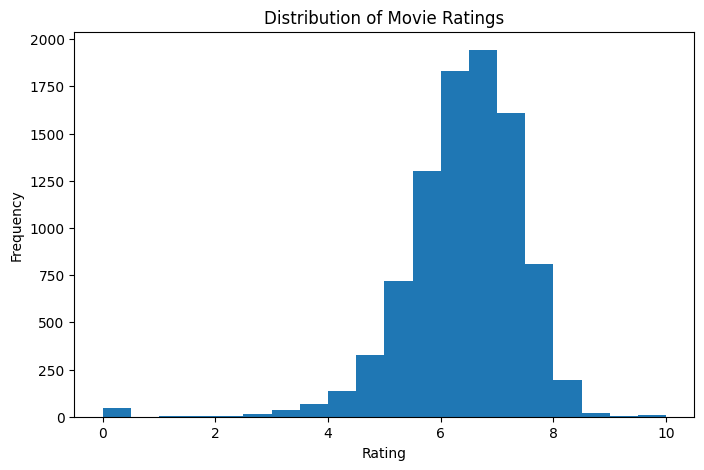

In [ ]:
# Rating Distribution
plt.figure(figsize=(8,5))

plt.hist(
    movies_df['vote_average'],
    bins=20
)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

Most movies have ratings between 6 and 7.5.

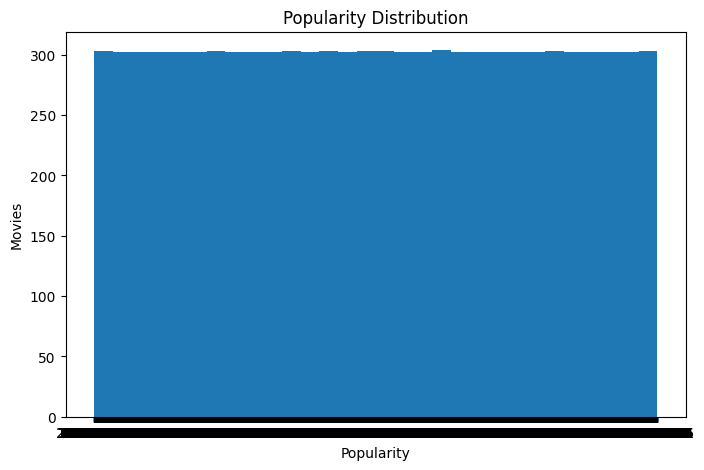

In [ ]:
# Popularity Distribution
plt.figure(figsize=(8,5))

plt.hist(
    movies_df['popularity'],
    bins=30
)

plt.title("Popularity Distribution")
plt.xlabel("Popularity")
plt.ylabel("Movies")

plt.show()

A small number of movies are extremely popular, while most have relatively low popularity

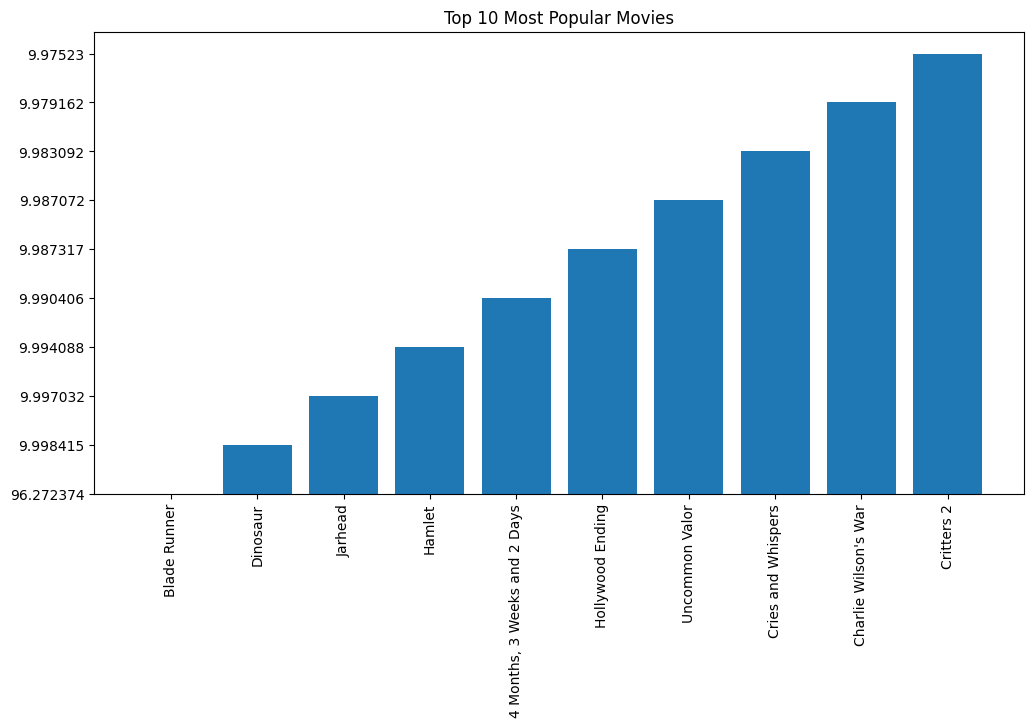

In [ ]:
# Top 10 Most Popular Movies
top_movies = movies_df.sort_values(
    by='popularity',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_movies['title'],
    top_movies['popularity']
)

plt.xticks(rotation=90)

plt.title("Top 10 Most Popular Movies")

plt.show()

In [ ]:
# Top Rated Movies
top_rated = movies_df[
    movies_df['vote_count'] > 100
].sort_values(
    by='vote_average',
    ascending=False
).head(10)

top_rated[['title','vote_average']]

,title,vote_average
689,The Godfather,8.5
283,The Shawshank Redemption,8.5
7109,Dear Zachary: A Letter to a Son About His Father,8.4
4218,Spirited Away,8.3
976,Once Upon a Time in America,8.3
266,Pulp Fiction,8.3
8578,Whiplash,8.3
968,Psycho,8.3
944,One Flew Over the Cuckoo's Nest,8.3
970,The Godfather: Part II,8.3


In [ ]:
# Movies Released Per Year
movies_df['release_date'] = pd.to_datetime(
    movies_df['release_date'],
    errors='coerce'
)

movies_df['release_year'] = movies_df['release_date'].dt.year

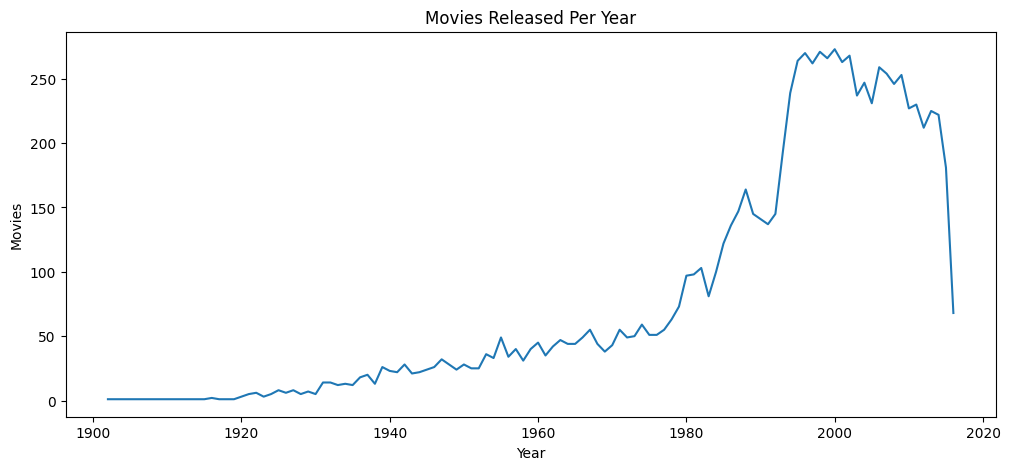

In [ ]:
movies_df['release_year'].value_counts().sort_index().plot(
    figsize=(12,5)
)

plt.title("Movies Released Per Year")

plt.xlabel("Year")

plt.ylabel("Movies")

plt.show()

Movie production increased significantly after the 1980s.

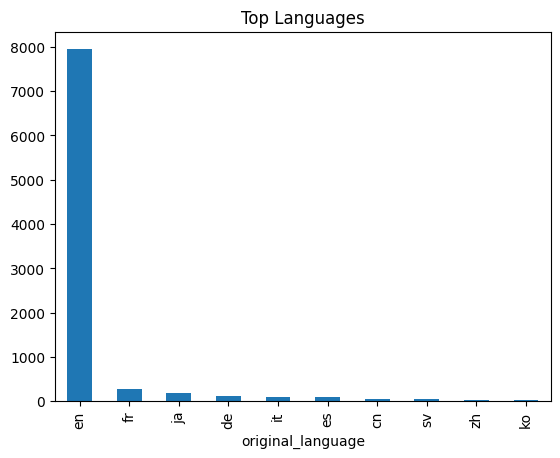

In [ ]:
# Top Languages
movies_df['original_language'].value_counts().head(10).plot(
    kind='bar'
)

plt.title("Top Languages")

plt.show()

English is the dominant language, followed by French, Japanese, and Spanish.

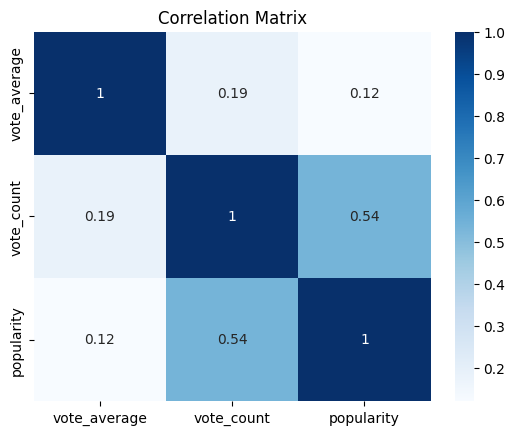

In [ ]:
# Correlation Heatmap
corr = movies_df[
    ['vote_average','vote_count','popularity']
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Matrix")

plt.show()

Popularity and vote count usually have a positive relationship, while vote average often has a weaker correlation with popularity.

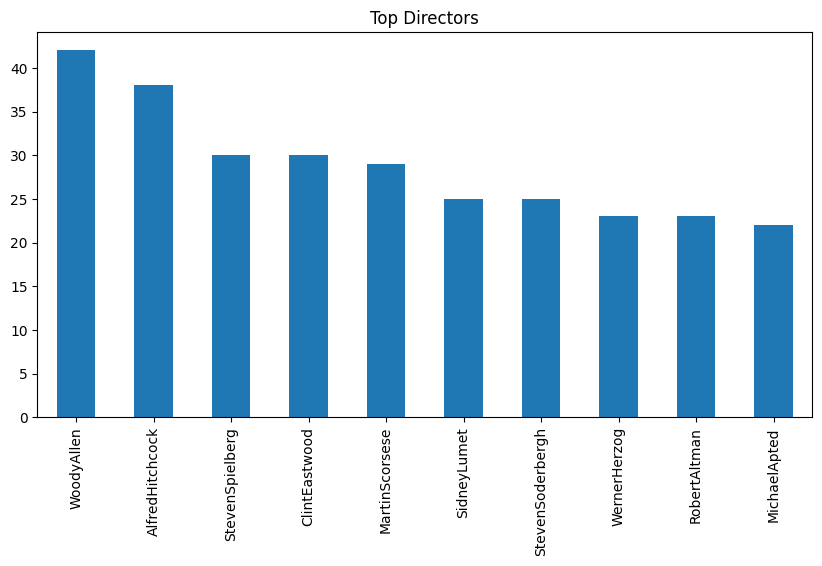

In [ ]:
# Top Directors
director_list = []

for director in movies_df['director']:
    director_list.extend(director)

director_df = pd.Series(director_list).value_counts().head(10)
director_df.plot(kind='bar', figsize=(10,5))

plt.title("Top Directors")

plt.show()

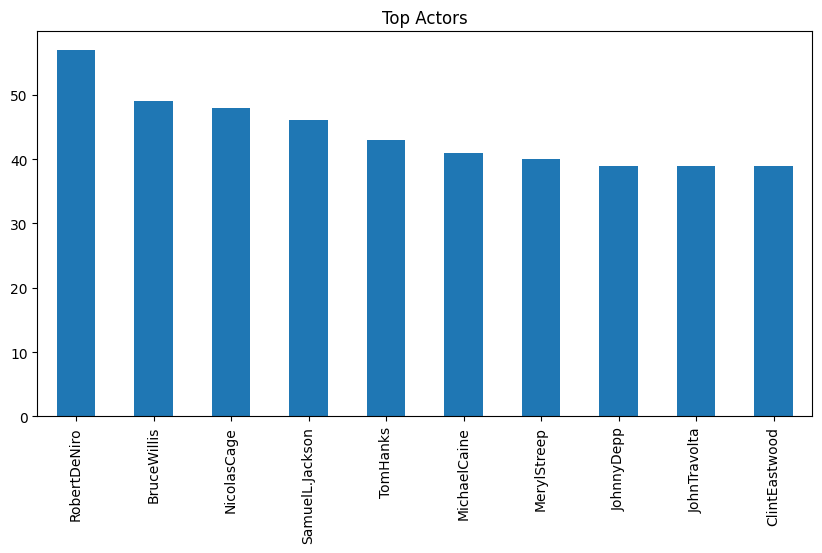

In [ ]:
# Top Actors
actor_list = []

for cast in movies_df['cast']:
    actor_list.extend(cast)

actor_df = pd.Series(actor_list).value_counts().head(10)
actor_df.plot(kind='bar', figsize=(10,5))

plt.title("Top Actors")

plt.show()

In [ ]:
# Top 10 Most Rated Movies
most_rated = ratings_df.groupby('movieId')['rating'].count().sort_values(
    ascending=False
).head(10)

most_rated

,rating
movieId,
356,341
296,324
318,311
593,304
260,291
480,274
2571,259
1,247
527,244


# Content-Based Recommendation System

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
final_movies.head()

,movie_id,movieId,title,tags,vote_average,popularity
0,862,1,Toy Story,"led by woody, andy's toys live happily in his ...",7.7,21.946943
1,8844,2,Jumanji,when siblings judy and peter discover an encha...,6.9,17.015539
2,15602,3,Grumpier Old Men,a family wedding reignites the ancient feud be...,6.5,11.7129
3,31357,4,Waiting to Exhale,"cheated on, mistreated and stepped on, the wom...",6.1,3.859495
4,11862,5,Father of the Bride Part II,just when george banks has recovered from his ...,5.7,8.387519


In [ ]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

tfidf_matrix = tfidf.fit_transform(final_movies['tags'])

In [ ]:
tfidf_matrix.shape

(9070, 5000)

In [ ]:
cosine_sim = cosine_similarity(tfidf_matrix)

In [ ]:
cosine_sim.shape

(9070, 9070)

In [ ]:
indices = pd.Series(
    final_movies.index,
    index=final_movies['title']
).drop_duplicates()

In [ ]:
indices.head()

,0
title,
Toy Story,0
Jumanji,1
Grumpier Old Men,2
Waiting to Exhale,3
Father of the Bride Part II,4


In [ ]:
# Recommendation Function
def content_recommend(movie_title, top_n=100):

    # Case-insensitive search
    matched = final_movies[
        final_movies["title"].str.lower() == movie_title.lower()
    ]

    if matched.empty:
        return pd.DataFrame({
            "Message": ["Movie not found."]
        })

    idx = matched.index[0]

    similarity_scores = list(enumerate(cosine_sim[idx]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:top_n+1]

    movie_indices = [i[0] for i in similarity_scores]

    recommendations = final_movies.iloc[movie_indices][
        ["movieId", "title"]
    ].copy()

    recommendations["Content Score"] = [
        score[1] for score in similarity_scores
    ]

    return recommendations.reset_index(drop=True)

In [ ]:
content_recommend("Toy Story")

,movieId,title,Content Score
0,78499,Toy Story 3,0.483250
1,3114,Toy Story 2,0.455043
2,35836,The 40 Year Old Virgin,0.349206
3,2041,Condorman,0.211451
4,7096,Rivers and Tides,0.187648
...,...,...,...
95,60128,Young People Fucking,0.061733
96,27646,Soldier's Girl,0.061461
97,3189,My Dog Skip,0.061442
98,76738,Steam of Life,0.061049


In [ ]:
content_recommend("The Dark Knight")

,movieId,title,Content Score
0,91529,The Dark Knight Rises,0.465963
1,79274,Batman: Under the Red Hood,0.402631
2,33794,Batman Begins,0.358479
3,1377,Batman Returns,0.355158
4,99813,"Batman: The Dark Knight Returns, Part 2",0.334550
...,...,...,...
95,92058,The Human Centipede 2 (Full Sequence),0.070544
96,92198,Seeking Justice,0.070542
97,6518,Flight of the Intruder,0.070371
98,60074,Hancock,0.070291


In [ ]:
content_recommend("toy story")

,movieId,title,Content Score
0,78499,Toy Story 3,0.483250
1,3114,Toy Story 2,0.455043
2,35836,The 40 Year Old Virgin,0.349206
3,2041,Condorman,0.211451
4,7096,Rivers and Tides,0.187648
...,...,...,...
95,60128,Young People Fucking,0.061733
96,27646,Soldier's Girl,0.061461
97,3189,My Dog Skip,0.061442
98,76738,Steam of Life,0.061049


In [ ]:
import pickle

pickle.dump(
    cosine_sim,
    open("models/cosine_similarity.pkl", "wb")
)

In [ ]:
pickle.dump(
    final_movies,
    open("models/final_movies.pkl", "wb")
)

# Collaborative Filtering (SVD)

In [ ]:
from surprise import Dataset
from surprise import Reader
from surprise import SVD
from surprise import accuracy
from surprise.model_selection import train_test_split

In [ ]:
ratings_df.head()

,userId,movieId,rating
0,1,31,2.5
1,1,1029,3.0
2,1,1061,3.0
3,1,1129,2.0
4,1,1172,4.0


In [ ]:
reader = Reader(rating_scale=(0.5, 5))

In [ ]:
data = Dataset.load_from_df(
    ratings_df[['userId', 'movieId', 'rating']],
    reader
)

In [ ]:
trainset, testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

In [ ]:
svd_model = SVD(
    n_factors=100,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)

svd_model.fit(trainset)

In [ ]:
predictions = svd_model.test(testset)

In [ ]:
rmse = accuracy.rmse(predictions)

mae = accuracy.mae(predictions)

RMSE: 0.9024
MAE:  0.6954


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Predict on the test set
predictions = svd_model.test(testset)

# Extract actual and predicted ratings
actual = [pred.r_ui for pred in predictions]
predicted = [pred.est for pred in predictions]

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(actual, predicted))

# Calculate MAE
mae = mean_absolute_error(actual, predicted)

print("RMSE:", round(rmse, 4))
print("MAE :", round(mae, 4))

RMSE: 0.9024
MAE : 0.6954


In [ ]:
# Predict a Single Rating
user_id = 100
movie_id = 1

prediction = svd_model.predict(
    uid=user_id,
    iid=movie_id
)

prediction.est

np.float64(3.882740072347804)

In [ ]:
def svd_recommend(user_id, ratings_df, final_movies, svd_model, top_n=None):

    watched_movies = ratings_df[
        ratings_df["userId"] == user_id
    ]["movieId"].tolist()

    unwatched = final_movies[
        ~final_movies["movieId"].isin(watched_movies)
    ].copy()

    unwatched["Collaborative Score"] = unwatched["movieId"].apply(
        lambda movie: svd_model.predict(user_id, movie).est
    )

    recommendations = unwatched.sort_values(
        "Collaborative Score",
        ascending=False
    )

    if top_n is not None:
        recommendations = recommendations.head(top_n)

    return recommendations[
        [
            "movieId",
            "title",
            "Collaborative Score"
        ]
    ]

In [ ]:
svd_recommend(
    user_id=100,
    ratings_df=ratings_df,
    final_movies=final_movies,
    svd_model=svd_model,
    top_n=10
)

,movieId,title,Collaborative Score
283,318,The Shawshank Redemption,4.502276
740,926,All About Eve,4.396394
970,1221,The Godfather: Part II,4.355164
924,1172,Cinema Paradiso,4.348767
1573,2019,Seven Samurai,4.340329
622,750,Dr. Strangelove or: How I Learned to Stop Worr...,4.295246
637,778,Trainspotting,4.256987
48,50,The Usual Suspects,4.245730
962,1213,GoodFellas,4.230907
521,589,Terminator 2: Judgment Day,4.228065


In [ ]:
import pickle

pickle.dump(
    svd_model,
    open("models/svd_model.pkl", "wb")
)

# Hybrid Recommendation System

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
from sklearn.preprocessing import MinMaxScaler

def hybrid_recommend(user_id,
                     movie_title,
                     content_weight,
                     collaborative_weight,
                     top_n=10):

    # Content-Based Recommendations
    content_df = content_recommend(movie_title, top_n=100)

    # Collaborative Recommendations
    collaborative_df = svd_recommend(
        user_id,
        ratings_df,
        final_movies,
        svd_model,
        top_n=None
    )

    # Merge Recommendations
    hybrid = pd.merge(
        content_df,
        collaborative_df,
        on=["movieId", "title"],
        how="inner"
    )

    # Normalize Scores
    scaler = MinMaxScaler()

    hybrid["Content Score"] = scaler.fit_transform(
        hybrid[["Content Score"]]
    )

    hybrid["Collaborative Score"] = scaler.fit_transform(
        hybrid[["Collaborative Score"]]
    )

    # Hybrid Score
    hybrid["Hybrid Score"] = (
        content_weight * hybrid["Content Score"] +
        collaborative_weight * hybrid["Collaborative Score"]
    )

    hybrid = hybrid.sort_values(
        "Hybrid Score",
        ascending=False
    )

    return hybrid.head(top_n)

In [ ]:
hybrid_model_50_50 = hybrid_recommend(
    user_id=100,
    movie_title="Toy Story",
    content_weight=0.5,
    collaborative_weight=0.5
)

print("Hybrid Model (50-50)")
display(hybrid_model_50_50)

Hybrid Model (50-50)


,movieId,title,Content Score,Collaborative Score,Hybrid Score
0,78499,Toy Story 3,1.000000,0.790296,0.895148
1,3114,Toy Story 2,0.933214,0.514276,0.723745
2,35836,The 40 Year Old Virgin,0.682625,0.676623,0.679624
38,318,The Shawshank Redemption,0.066995,1.000000,0.533498
4,7096,Rivers and Tides,0.300107,0.560728,0.430417
24,4886,"Monsters, Inc.",0.103494,0.683745,0.393619
62,48780,The Prestige,0.030226,0.749816,0.390021
20,766,I Shot Andy Warhol,0.129140,0.594545,0.361842
25,4822,Max Keeble's Big Move,0.102734,0.619494,0.361114
3,2041,Condorman,0.356465,0.346091,0.351278


In [ ]:
hybrid_model_60_40 = hybrid_recommend(
    user_id=100,
    movie_title="Toy Story",
    content_weight=0.6,
    collaborative_weight=0.4
)

print("Hybrid Model (60-40)")
display(hybrid_model_60_40)

Hybrid Model (60-40)


,movieId,title,Content Score,Collaborative Score,Hybrid Score
0,78499,Toy Story 3,1.000000,0.790296,0.916118
1,3114,Toy Story 2,0.933214,0.514276,0.765639
2,35836,The 40 Year Old Virgin,0.682625,0.676623,0.680224
38,318,The Shawshank Redemption,0.066995,1.000000,0.440197
4,7096,Rivers and Tides,0.300107,0.560728,0.404355
3,2041,Condorman,0.356465,0.346091,0.352316
24,4886,"Monsters, Inc.",0.103494,0.683745,0.335594
5,106022,Toy Story of Terror!,0.281822,0.411334,0.333626
62,48780,The Prestige,0.030226,0.749816,0.318062
8,490,Malice,0.233535,0.442656,0.317184


In [ ]:
hybrid_model_40_60 = hybrid_recommend(
    user_id=100,
    movie_title="Toy Story",
    content_weight=0.4,
    collaborative_weight=0.6
)

print("Hybrid Model (40-60)")
display(hybrid_model_40_60)

Hybrid Model (40-60)


,movieId,title,Content Score,Collaborative Score,Hybrid Score
0,78499,Toy Story 3,1.000000,0.790296,0.874177
1,3114,Toy Story 2,0.933214,0.514276,0.681851
2,35836,The 40 Year Old Virgin,0.682625,0.676623,0.679024
38,318,The Shawshank Redemption,0.066995,1.000000,0.626798
62,48780,The Prestige,0.030226,0.749816,0.461980
4,7096,Rivers and Tides,0.300107,0.560728,0.456480
24,4886,"Monsters, Inc.",0.103494,0.683745,0.451644
25,4822,Max Keeble's Big Move,0.102734,0.619494,0.412790
20,766,I Shot Andy Warhol,0.129140,0.594545,0.408383
87,3083,All About My Mother,0.008453,0.662575,0.400926


In [ ]:
print("Top Recommendation")
print("----------------------")

print("Hybrid Model (50-50)")
display(hybrid_model_50_50.head())

print("Hybrid Model (60-40)")
display(hybrid_model_60_40.head())

print("Hybrid Model (40-60)")
display(hybrid_model_40_60.head())

Top Recommendation
----------------------
Hybrid Model (50-50)


,movieId,title,Content Score,Collaborative Score,Hybrid Score
0,78499,Toy Story 3,1.000000,0.790296,0.895148
1,3114,Toy Story 2,0.933214,0.514276,0.723745
2,35836,The 40 Year Old Virgin,0.682625,0.676623,0.679624
38,318,The Shawshank Redemption,0.066995,1.000000,0.533498
4,7096,Rivers and Tides,0.300107,0.560728,0.430417


Hybrid Model (60-40)


,movieId,title,Content Score,Collaborative Score,Hybrid Score
0,78499,Toy Story 3,1.000000,0.790296,0.916118
1,3114,Toy Story 2,0.933214,0.514276,0.765639
2,35836,The 40 Year Old Virgin,0.682625,0.676623,0.680224
38,318,The Shawshank Redemption,0.066995,1.000000,0.440197
4,7096,Rivers and Tides,0.300107,0.560728,0.404355


Hybrid Model (40-60)


,movieId,title,Content Score,Collaborative Score,Hybrid Score
0,78499,Toy Story 3,1.000000,0.790296,0.874177
1,3114,Toy Story 2,0.933214,0.514276,0.681851
2,35836,The 40 Year Old Virgin,0.682625,0.676623,0.679024
38,318,The Shawshank Redemption,0.066995,1.000000,0.626798
62,48780,The Prestige,0.030226,0.749816,0.461980


Create an Evaluation Function

In [ ]:
def evaluate_hybrid(hybrid_df):

    metrics = {
        "Average Hybrid Score": hybrid_df["Hybrid Score"].mean(),
        "Maximum Hybrid Score": hybrid_df["Hybrid Score"].max(),
        "Minimum Hybrid Score": hybrid_df["Hybrid Score"].min(),
        "Average Content Score": hybrid_df["Content Score"].mean(),
        "Average Collaborative Score": hybrid_df["Collaborative Score"].mean()
    }

    return metrics

In [ ]:
eval_50_50 = evaluate_hybrid(hybrid_model_50_50)
eval_60_40 = evaluate_hybrid(hybrid_model_60_40)
eval_40_60 = evaluate_hybrid(hybrid_model_40_60)

In [ ]:
comparison_df = pd.DataFrame({

    "Hybrid Model":[
        "50% Content + 50% Collaborative",
        "60% Content + 40% Collaborative",
        "40% Content + 60% Collaborative"
    ],

    "Average Hybrid Score":[
        eval_50_50["Average Hybrid Score"],
        eval_60_40["Average Hybrid Score"],
        eval_40_60["Average Hybrid Score"]
    ],

    "Maximum Hybrid Score":[
        eval_50_50["Maximum Hybrid Score"],
        eval_60_40["Maximum Hybrid Score"],
        eval_40_60["Maximum Hybrid Score"]
    ],

    "Average Content Score":[
        eval_50_50["Average Content Score"],
        eval_60_40["Average Content Score"],
        eval_40_60["Average Content Score"]
    ],

    "Average Collaborative Score":[
        eval_50_50["Average Collaborative Score"],
        eval_60_40["Average Collaborative Score"],
        eval_40_60["Average Collaborative Score"]
    ]

})

comparison_df

,Hybrid Model,Average Hybrid Score,Maximum Hybrid Score,Average Content Score,Average Collaborative Score
0,50% Content + 50% Collaborative,0.512031,0.895148,0.370500,0.653561
1,60% Content + 40% Collaborative,0.486332,0.916118,0.398848,0.617557
2,40% Content + 60% Collaborative,0.545405,0.874177,0.335699,0.685210


In [ ]:
best_model = comparison_df.loc[
    comparison_df["Average Hybrid Score"].idxmax()
]

print("Best Hybrid Model")
print(best_model)

Best Hybrid Model
Hybrid Model                   40% Content + 60% Collaborative
Average Hybrid Score                                  0.545405
Maximum Hybrid Score                                  0.874177
Average Content Score                                 0.335699
Average Collaborative Score                            0.68521
Name: 2, dtype: object


In [ ]:
print("Best Hybrid Model:")
display(best_model.to_frame())

Best Hybrid Model:


,2
Hybrid Model,40% Content + 60% Collaborative
Average Hybrid Score,0.545405
Maximum Hybrid Score,0.874177
Average Content Score,0.335699
Average Collaborative Score,0.68521


# Model Evaluation

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
recommended = hybrid_model_40_60.head(10)

precision_at_10 = (
    recommended["Hybrid Score"] >= 0.65
).sum() / len(recommended)

print("Precision@10 :", round(precision_at_10,4))

Precision@10 : 0.3


In [ ]:
print("Relevant Movies:", relevant_movies)
print("Retrieved Relevant:", retrieved_relevant)

Relevant Movies: 1
Retrieved Relevant: 1


In [ ]:
relevant_movies = (
    hybrid_model_40_60["Hybrid Score"] >= 0.65
).sum()

retrieved_relevant = (
    recommended["Hybrid Score"] >= 0.65
).sum()

if relevant_movies == 0:
    recall_at_10 = 0
else:
    recall_at_10 = retrieved_relevant / relevant_movies

print("Recall@10 :", round(recall_at_10,4))

Recall@10 : 1.0


In [ ]:
evaluation_df = pd.DataFrame({

    "Metric":["Precision@10","Recall@10"],

    "Value":[precision_at_10,recall_at_10]
})

evaluation_df

,Metric,Value
0,Precision@10,0.3
1,Recall@10,1.0


# Explainable AI (Plain-English Explanations)

In [ ]:
def explain_recommendations(recommendations, movie_title):

    explanations = []

    for _, row in recommendations.iterrows():

        explanation = (
            f'"{row["title"]}" is recommended because it is similar to '
            f'"{movie_title}" based on its content features such as genres, '
            f'keywords, cast, and storyline. It also received a high '
            f'Collaborative Score from users with similar viewing preferences. '
            f'The combined Hybrid Score of {row["Hybrid Score"]:.2f} makes it '
            f'one of the top recommendations.'
        )

        explanations.append(explanation)

    recommendations["Explanation"] = explanations

    return recommendations

In [ ]:
explained_movies = explain_recommendations(
    hybrid_model_40_60,
    "Toy Story"
)

explained_movies[
    [
        "title",
        "Hybrid Score",
        "Explanation"
    ]
]

,title,Hybrid Score,Explanation
0,Toy Story 3,0.874177,"""Toy Story 3"" is recommended because it is sim..."
1,Toy Story 2,0.681851,"""Toy Story 2"" is recommended because it is sim..."
2,The 40 Year Old Virgin,0.679024,"""The 40 Year Old Virgin"" is recommended becaus..."
38,The Shawshank Redemption,0.626798,"""The Shawshank Redemption"" is recommended beca..."
62,The Prestige,0.461980,"""The Prestige"" is recommended because it is si..."
4,Rivers and Tides,0.456480,"""Rivers and Tides"" is recommended because it i..."
24,"Monsters, Inc.",0.451644,"""Monsters, Inc."" is recommended because it is ..."
25,Max Keeble's Big Move,0.412790,"""Max Keeble's Big Move"" is recommended because..."
20,I Shot Andy Warhol,0.408383,"""I Shot Andy Warhol"" is recommended because it..."
87,All About My Mother,0.400926,"""All About My Mother"" is recommended because i..."


In [ ]:
import pickle

pickle.dump(tfidf, open("models/tfidf.pkl", "wb"))
pickle.dump(cosine_sim, open("models/cosine_similarity.pkl", "wb"))
pickle.dump(svd_model, open("models/svd_model.pkl", "wb"))
pickle.dump(final_movies, open("models/final_movies.pkl", "wb"))
pickle.dump(ratings_df, open("models/ratings.pkl", "wb"))

In [ ]:
import os

print(os.listdir("models"))

['ratings.pkl', 'final_movies.pkl', 'tfidf.pkl', 'svd_model.pkl', 'cosine_similarity.pkl']


In [ ]:
import os

print(os.listdir())

['.config', 'data', 'models', '.ipynb_checkpoints', 'sample_data']


In [ ]:
import zipfile
import os

zip_name = "AI_Movie_recommender_final.zip"

with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as zipf:

    # Add models folder
    for root, dirs, files in os.walk("models"):
        for file in files:
            file_path = os.path.join(root, file)
            zipf.write(file_path)

    # Add data folder
    for root, dirs, files in os.walk("data"):
        for file in files:
            file_path = os.path.join(root, file)
            zipf.write(file_path)

print("ZIP file created successfully!")

ZIP file created successfully!


In [ ]:
from google.colab import files

files.download("AI_Movie_recommender_final.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>